<a href="https://colab.research.google.com/github/harshav6/deepLearning/blob/main/LeNet_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow
import numpy as np
from tensorflow import keras
from keras.layers import Dense, Flatten, Conv2D, AveragePooling2D
from keras import Sequential
from keras.datasets import mnist
import matplotlib.pyplot as plt

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [ ]:
print(X_train.shape)

(60000, 28, 28)


In [ ]:
X_train = np.pad(X_train, ((0,0), (2,2), (2,2)), mode='constant')
X_test = np.pad(X_test, ((0,0), (2,2), (2,2)), mode = 'constant')
print(X_train.shape)

(60000, 32, 32)


LeNet Architecture

In [ ]:
model = Sequential()

model.add(Conv2D(6, kernel_size = (5,5), padding = 'valid', activation = 'tanh', input_shape = (32,32,1)))
model.add(AveragePooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))

model.add(Conv2D(16, kernel_size = (5,5), padding = 'valid', activation = 'tanh'))
model.add(AveragePooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))

model.add(Flatten())

model.add(Dense(120, activation = 'tanh'))
model.add(Dense(84, activation = 'tanh'))
model.add(Dense(10, activation = 'softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

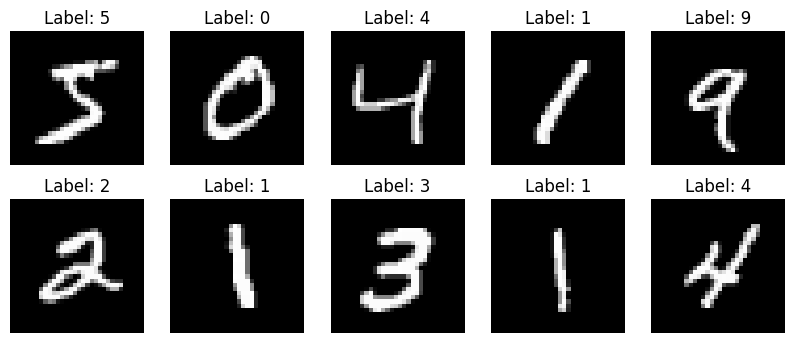

In [ ]:
plt.figure(figsize = (10,4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(X_train[i], cmap = 'gray')
  plt.title(f"Label: {y_train[i]}")
  plt.axis('off')
plt.show()

In [ ]:
X_train_main = X_train[:50000]
y_train_main = y_train[:50000]

x_val = X_train[50000:]
y_val = y_train[50000:]

In [ ]:
X_train_main = X_train_main / 255.0
x_val = x_val / 255.0
X_test = X_test / 255.0

In [ ]:
#Re-Shape data

X_train_main = X_train_main.reshape(50000, 32, 32, 1)
x_val = x_val.reshape(10000, 32, 32, 1)
X_test = X_test.reshape(10000, 32, 32, 1)

In [ ]:
#One Hot Encoding of the output values

y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

In [ ]:
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [ ]:
model. fit(X_train_main, y_train_main, epochs = 10, batch_size = 128, validation_data = (x_val, y_val))

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 36s 87ms/step - accuracy: 0.8950 - loss: 0.3651 - val_accuracy: 0.9542 - val_loss: 0.1576
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.9575 - loss: 0.1378 - val_accuracy: 0.9684 - val_loss: 0.1105
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9720 - loss: 0.0912 - val_accuracy: 0.9755 - val_loss: 0.0855
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 74ms/step - accuracy: 0.9800 - loss: 0.0658 - val_accuracy: 0.9779 - val_loss: 0.0755
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9840 - loss: 0.0525 - val_accuracy: 0.9787 - val_loss: 0.0700
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 79ms/step - accuracy: 0.9877 - loss: 0.0414 - val_accuracy: 0.9826 - val_loss: 0.0592
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 74ms/step - accuracy: 0.9884 - loss: 0.0361 - val_accuracy: 0.9811 - val_loss: 0.0628
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9920 - loss: 0.0279 - 

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9843 - loss: 0.0479
Test accuracy: 0.9843000173568726
